IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, 
                             ConfusionMatrixDisplay,
                             roc_auc_score, 
                             roc_curve,
                             classification_report)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

LOAD DATASET & SPLIT DATA

In [7]:
df = pd.read_csv("startup_cleaned_dataset.csv")
df["status"] = df["status"].map({"acquired": 1, "closed": 0})
df_encoded = pd.get_dummies(df, columns=["state_code", "category_code"], drop_first=True)

X = df_encoded[[
    "funding_total_usd", "funding_rounds", "milestones",
    "relationships", "avg_participants", "is_top500",
    "age_first_funding_year", "age_last_funding_year",
    "age_first_milestone_year", "age_last_milestone_year",
    "has_VC", "has_angel", "has_roundA", "has_roundB",
    "has_roundC", "has_roundD",
    "is_software", "is_web", "is_mobile", "is_enterprise",
    "is_biotech", "is_CA", "is_NY", "is_MA", "is_TX"
]]
y = df_encoded["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

LOAD SAVED MODEL AND SCALER

In [10]:
with open("best_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

X_test_sc = scaler.transform(X_test)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

CONFUSION MATRIC

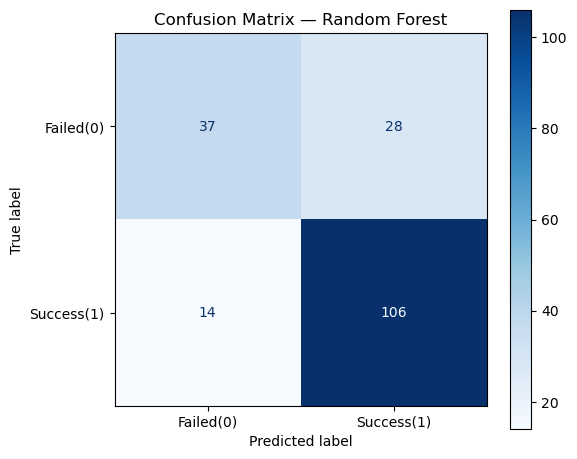

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Failed(0)", "Success(1)"]
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

ROC CURVE

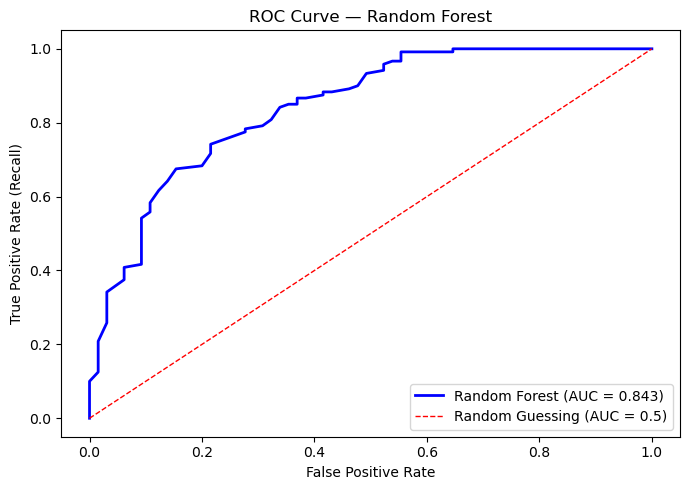

In [13]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 
         color='blue', 
         linewidth=2,
         label=f'Random Forest (AUC = 0.843)')

plt.plot([0, 1], [0, 1], 
         color='red', 
         linestyle='--', 
         linewidth=1,
         label='Random Guessing (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()